<a href="https://colab.research.google.com/github/Anton3090/Medical-detection/blob/main/Medical-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: Mount Drive & Install Dependencies
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q
!pip install scikit-learn matplotlib seaborn pandas -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 2: Imports
# ============================================================
import os, shutil, random, yaml, time, datetime, threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image
from collections import deque, defaultdict
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

random.seed(42)
np.random.seed(42)

print("✅ Libraries loaded")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries loaded


In [ ]:
# ============================================================
# CELL 3: Configuration for PPE Dataset
# ============================================================
SOURCE_DATASET = Path("/content/drive/MyDrive/augmented_dataset")
YOLO_DIR       = Path("/content/ppe_yolo_dataset")

# 7 PPE classes (folder names in your dataset)
CLASS_NAMES = ["cap", "face_mask", "gloves","gown", "shoe_cover"]

CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

# Training settings
IMG_SIZE   = 640
BATCH_SIZE = 16
SEED       = 42
PROJECT    = "ppe_detection"

print(f" Source : {SOURCE_DATASET}")
print(f" Output : {YOLO_DIR}")
print(f" Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

# Verify source exists
assert SOURCE_DATASET.exists(), f" Path not found: {SOURCE_DATASET}"
for cls in CLASS_NAMES:
    p = SOURCE_DATASET / cls
    if p.exists():
        n = len(list(p.glob("*.*")))
        print(f"    {cls:<15} : {n} images")
    else:
        print(f"    {cls:<15} : NOT FOUND")

 Source : /content/drive/MyDrive/augmented_dataset
 Output : /content/ppe_yolo_dataset
 Classes (5): ['cap', 'face_mask', 'gloves', 'gown', 'shoe_cover']
    cap             : 564 images
    face_mask       : 378 images
    gloves          : 498 images
    gown            : 552 images
    shoe_cover      : 600 images


In [ ]:
# ============================================================
# CELL 4 (FIXED): Convert Classification → YOLO Detection Format
# SAFE + REPRODUCIBLE + NO DATA LEAKAGE VERSION
# ============================================================

import random
import shutil
from pathlib import Path
from collections import defaultdict

# ------------------------------------------------------------
# Helper: YOLO label generator
# ------------------------------------------------------------
def make_yolo_label(class_id, padding=0.025):
    cx, cy = 0.5, 0.5
    w = 1.0 - 2 * padding
    h = 1.0 - 2 * padding
    return f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n"


# ============================================================
# MAIN FUNCTION (FIXED)
# ============================================================
def convert_to_yolo(source_dir, yolo_dir,
                    train_r=0.70, val_r=0.20, test_r=0.10,
                    seed=42):

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------
    random.seed(seed)

    # --------------------------------------------------------
    # Clean output folder
    # --------------------------------------------------------
    if yolo_dir.exists():
        shutil.rmtree(yolo_dir)

    for split in ["train", "val", "test"]:
        (yolo_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (yolo_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------------
    # Global dataset (IMPORTANT FIX)
    # --------------------------------------------------------
    all_data = []   # (img_path, class_id, class_name)

    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    for cls_name in CLASS_NAMES:
        cls_dir = source_dir / cls_name

        if not cls_dir.exists():
            print(f"⚠️ Missing class: {cls_name}")
            continue

        cls_id = CLASS_TO_ID[cls_name]

        for img_path in cls_dir.rglob("*"):
            if img_path.suffix.lower() in exts:
                all_data.append((img_path, cls_id, cls_name))

    # --------------------------------------------------------
    # GLOBAL shuffle (CRITICAL FIX)
    # --------------------------------------------------------
    random.shuffle(all_data)

    n = len(all_data)
    n_test = int(n * test_r)
    n_val = int(n * val_r)

    splits = {
        "test": all_data[:n_test],
        "val": all_data[n_test:n_test + n_val],
        "train": all_data[n_test + n_val:]
    }

    # --------------------------------------------------------
    # Stats
    # --------------------------------------------------------
    split_counts = {"train": 0, "val": 0, "test": 0}
    per_class = defaultdict(lambda: defaultdict(int))

    # --------------------------------------------------------
    # Write dataset
    # --------------------------------------------------------
    for split, items in splits.items():

        for i, (src, cls_id, cls_name) in enumerate(items):

            new_name = f"{src.stem}_{i}{src.suffix.lower()}"

            dst_img = yolo_dir / "images" / split / new_name
            dst_lbl = yolo_dir / "labels" / split / (Path(new_name).stem + ".txt")

            shutil.copy(src, dst_img)

            with open(dst_lbl, "w") as f:
                f.write(make_yolo_label(cls_id))

            split_counts[split] += 1
            per_class[cls_name][split] += 1

    return split_counts, per_class


# ============================================================
# RUN CONVERSION
# ============================================================
print("🔄 Converting dataset → YOLO format (FIXED VERSION)...")

split_counts, per_class = convert_to_yolo(SOURCE_DATASET, YOLO_DIR)

# ============================================================
# SUMMARY
# ============================================================
print("\n📊 Split Summary")
print("─" * 40)

total = sum(split_counts.values())

for s, c in split_counts.items():
    pct = (c / total * 100) if total > 0 else 0
    print(f"{s:>5}: {c:>5} images ({pct:.1f}%)")

print(f"{'TOTAL':>5}: {total}")

🔄 Converting dataset → YOLO format (FIXED VERSION)...

📊 Split Summary
────────────────────────────────────────
train:  1815 images (70.0%)
  val:   518 images (20.0%)
 test:   259 images (10.0%)
TOTAL: 2592


            train  val  test  total
gown          381  121    50    552
face_mask     272   68    38    378
cap           392  110    62    564
gloves        366   84    48    498
shoe_cover    404  135    61    600


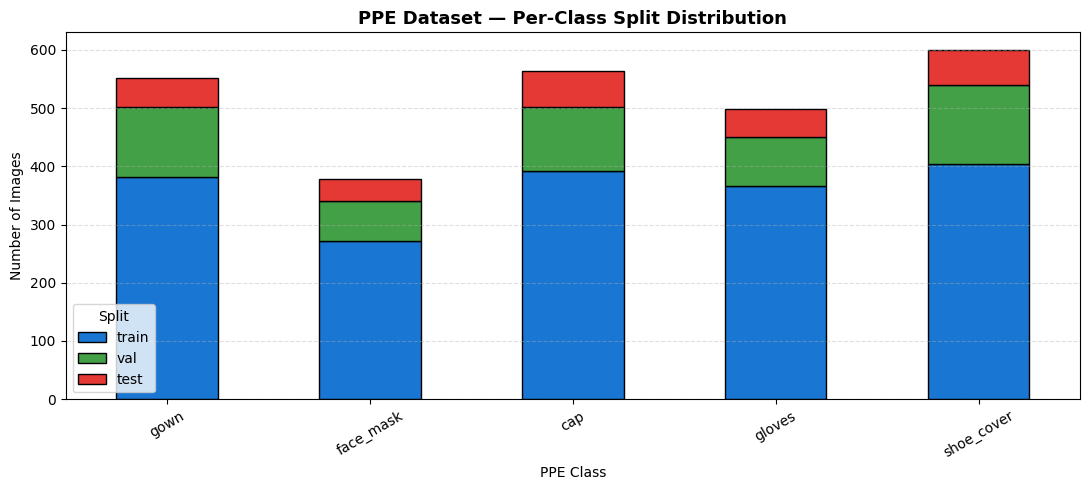

In [ ]:
# ============================================================
# CELL 5: Per-Class Distribution Visualisation
# ============================================================
df_dist = pd.DataFrame(per_class).T.fillna(0).astype(int)
df_dist = df_dist[["train", "val", "test"]]
df_dist["total"] = df_dist.sum(axis=1)
print(df_dist)

fig, ax = plt.subplots(figsize=(11, 5))
df_dist[["train", "val", "test"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=["#1976D2", "#43A047", "#E53935"], edgecolor="black"
)
ax.set_title("PPE Dataset — Per-Class Split Distribution",
             fontsize=13, fontweight="bold")
ax.set_xlabel("PPE Class")
ax.set_ylabel("Number of Images")
ax.legend(title="Split")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("ppe_split_distribution.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# CELL 6: Generate data.yaml
# ============================================================
def write_yaml():
    cfg = {
        "path"  : str(YOLO_DIR.resolve()),
        "train" : "images/train",
        "val"   : "images/val",
        "test"  : "images/test",
        "nc"    : len(CLASS_NAMES),
        "names" : CLASS_NAMES,
    }
    yaml_path = "/content/ppe_data.yaml"
    with open(yaml_path, "w") as f:
        yaml.dump(cfg, f, default_flow_style=False)
    print(f"✅ data.yaml saved: {yaml_path}")
    print(yaml.dump(cfg))
    return yaml_path

YAML_PATH = write_yaml()

✅ data.yaml saved: /content/ppe_data.yaml
names:
- cap
- face_mask
- gloves
- gown
- shoe_cover
nc: 5
path: /content/ppe_yolo_dataset
test: images/test
train: images/train
val: images/val



In [ ]:
# ============================================================
# CELL 7: Two Hyperparameter Configurations
# ============================================================
config1 = {
    "name"     : "Config1_YOLOv8n_Baseline",
    "model"    : "yolov8n.pt",
    "epochs"   : 30,
    "batch"    : 16,
    "imgsz"    : 640,
    "lr0"      : 0.01,
    "lrf"      : 0.01,
    "optimizer": "SGD",
    "dropout"  : 0.0,
}

config2 = {
    "name"     : "Config2_YOLOv8s_Tuned",
    "model"    : "yolov8s.pt",
    "epochs"   : 50,
    "batch"    : 16,
    "imgsz"    : 640,
    "lr0"      : 0.005,
    "lrf"      : 0.001,
    "optimizer": "AdamW",
    "dropout"  : 0.1,
}

print("  Hyperparameter Configurations")
print("─" * 65)
print(f"{'Param':<14}{'Config 1':<25}{'Config 2'}")
print("─" * 65)
for k in config1:
    flag = " ← differs" if config1[k] != config2[k] else ""
    print(f"{k:<14}{str(config1[k]):<25}{config2[k]}{flag}")

  Hyperparameter Configurations
─────────────────────────────────────────────────────────────────
Param         Config 1                 Config 2
─────────────────────────────────────────────────────────────────
name          Config1_YOLOv8n_Baseline Config2_YOLOv8s_Tuned ← differs
model         yolov8n.pt               yolov8s.pt ← differs
epochs        30                       50 ← differs
batch         16                       16
imgsz         640                      640
lr0           0.01                     0.005 ← differs
lrf           0.01                     0.001 ← differs
optimizer     SGD                      AdamW ← differs
dropout       0.0                      0.1 ← differs


In [ ]:
# ============================================================
# CELL 8: Train Configuration 1 (YOLOv8n Baseline)
# ============================================================
print(" Training Config 1 — YOLOv8n Baseline")
print("=" * 60)

model_c1 = YOLO(config1["model"])
results_c1 = model_c1.train(
    data       = YAML_PATH,
    epochs     = config1["epochs"],
    batch      = config1["batch"],
    imgsz      = config1["imgsz"],
    lr0        = config1["lr0"],
    lrf        = config1["lrf"],
    optimizer  = config1["optimizer"],
    dropout    = config1["dropout"],
    project    = PROJECT,
    name       = config1["name"],
    seed       = SEED,
    plots      = True,
    verbose    = True,
)
print("✅ Config 1 done")

 Training Config 1 — YOLOv8n Baseline
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Config1_YOLOv8n_Baseline, nbs=64, nms=False, opset=None, optimize=False

In [ ]:
# ============================================================
# CELL 9: Train Configuration 2 (YOLOv8s Tuned)
# ============================================================
print(" Training Config 2 — YOLOv8s Tuned")
print("=" * 60)

model_c2 = YOLO(config2["model"])
results_c2 = model_c2.train(
    data       = YAML_PATH,
    epochs     = config2["epochs"],
    batch      = config2["batch"],
    imgsz      = config2["imgsz"],
    lr0        = config2["lr0"],
    lrf        = config2["lrf"],
    optimizer  = config2["optimizer"],
    dropout    = config2["dropout"],
    project    = PROJECT,
    name       = config2["name"],
    seed       = SEED,
    plots      = True,
    verbose    = True,
)
print("✅ Config 2 done")

 Training Config 2 — YOLOv8s Tuned
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Config2_YOLOv8s_Tuned, nbs=64, nms=False, opset=None, optimize=False, op

In [ ]:
# ============================================================
# CELL 10: Evaluate Both Models on Test Set
# ============================================================


# ------------------------------------------------------------
# Base runs directory
# ------------------------------------------------------------
RUNS_DIR = Path("/content/runs/detect")

# ------------------------------------------------------------
# Config 1 best model path
# ------------------------------------------------------------
best_c1 = (
    RUNS_DIR /
    PROJECT /
    config1["name"] /
    "weights" /
    "best.pt"
)

# ------------------------------------------------------------
# Config 2 best model path
# ------------------------------------------------------------
best_c2 = (
    RUNS_DIR /
    PROJECT /
    config2["name"] /
    "weights" /
    "best.pt"
)

# ------------------------------------------------------------
# Check files exist
# ------------------------------------------------------------
print("Checking model files...\n")

print("Config1 path:", best_c1)
print("Exists:", best_c1.exists())

print("\nConfig2 path:", best_c2)
print("Exists:", best_c2.exists())

# ------------------------------------------------------------
# Load models
# ------------------------------------------------------------
model_c1_best = YOLO(str(best_c1))
model_c2_best = YOLO(str(best_c2))

# ------------------------------------------------------------
# Evaluate Config 1
# ------------------------------------------------------------
print("\n📊 Evaluating Config 1 on test set...")

metrics_c1 = model_c1_best.val(
    data=YAML_PATH,
    split="test",
    imgsz=IMG_SIZE,
    project=PROJECT,
    name="eval_c1",
    plots=True,
)

# ------------------------------------------------------------
# Evaluate Config 2
# ------------------------------------------------------------
print("\n📊 Evaluating Config 2 on test set...")

metrics_c2 = model_c2_best.val(
    data=YAML_PATH,
    split="test",
    imgsz=IMG_SIZE,
    project=PROJECT,
    name="eval_c2",
    plots=True,
)

# ------------------------------------------------------------
# Print Final Results
# ------------------------------------------------------------
print("\n" + "=" * 50)
print("📈 FINAL TEST RESULTS")
print("=" * 50)

print("\n🔹 Config 1")
print(f"mAP50      : {metrics_c1.box.map50:.4f}")
print(f"mAP50-95   : {metrics_c1.box.map:.4f}")
print(f"Precision  : {metrics_c1.box.mp:.4f}")
print(f"Recall     : {metrics_c1.box.mr:.4f}")

print("\n🔹 Config 2")
print(f"mAP50      : {metrics_c2.box.map50:.4f}")
print(f"mAP50-95   : {metrics_c2.box.map:.4f}")
print(f"Precision  : {metrics_c2.box.mp:.4f}")
print(f"Recall     : {metrics_c2.box.mr:.4f}")

print("\n✅ Evaluation Complete")

In [ ]:
# ============================================================
# CELL 11: Compare Configurations
# ============================================================
def extract(metrics, name):
    p, r = metrics.box.mp, metrics.box.mr
    return {
        "Config"   : name,
        "mAP@50"   : round(metrics.box.map50, 4),
        "mAP@50-95": round(metrics.box.map,   4),
        "Precision": round(p, 4),
        "Recall"   : round(r, 4),
        "F1"       : round(2*p*r / (p + r + 1e-9), 4),
    }

row1 = extract(metrics_c1, config1["name"])
row2 = extract(metrics_c2, config2["name"])

df_cmp = pd.DataFrame([row1, row2]).set_index("Config")
print("\n📈 Configuration Comparison (Test Set)")
print("=" * 65)
print(df_cmp.to_string())

winner_name = df_cmp["mAP@50"].idxmax()
print(f"\n🏆 WINNER: {winner_name}")
print(f"   mAP@50 = {df_cmp.loc[winner_name, 'mAP@50']}")

best_model = model_c2_best if winner_name == config2["name"] else model_c1_best
best_weights = best_c2 if winner_name == config2["name"] else best_c1
best_metrics_obj = metrics_c2 if winner_name == config2["name"] else metrics_c1


📈 Configuration Comparison (Test Set)
                          mAP@50  mAP@50-95  Precision  Recall      F1
Config                                                                
Config1_YOLOv8n_Baseline  0.9938     0.9938     0.9928  0.9811  0.9869
Config2_YOLOv8s_Tuned     0.9950     0.9950     0.9956  0.9957  0.9957

🏆 WINNER: Config2_YOLOv8s_Tuned
   mAP@50 = 0.995


In [ ]:
# ============================================================
# CELL 12: Comparison Bar Chart
# ============================================================
metrics_cols = ["mAP@50", "mAP@50-95", "Precision", "Recall", "F1"]
x = np.arange(len(metrics_cols))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, df_cmp.iloc[0][metrics_cols], w,
            label=config1["name"], color="#1565C0", edgecolor="black")
b2 = ax.bar(x + w/2, df_cmp.iloc[1][metrics_cols], w,
            label=config2["name"], color="#E65100", edgecolor="black")

for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2,
            b.get_height() + 0.005,
            f"{b.get_height():.3f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.1)
ax.set_title("Config 1 vs Config 2 — Test Set Performance",
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("config_comparison.png", dpi=150)
plt.show()

📋 Per-Class Performance (Best Model)
 PPE Class  AP@50
       cap  0.995
 face_mask  0.995
    gloves  0.995
      gown  0.995
shoe_cover  0.995


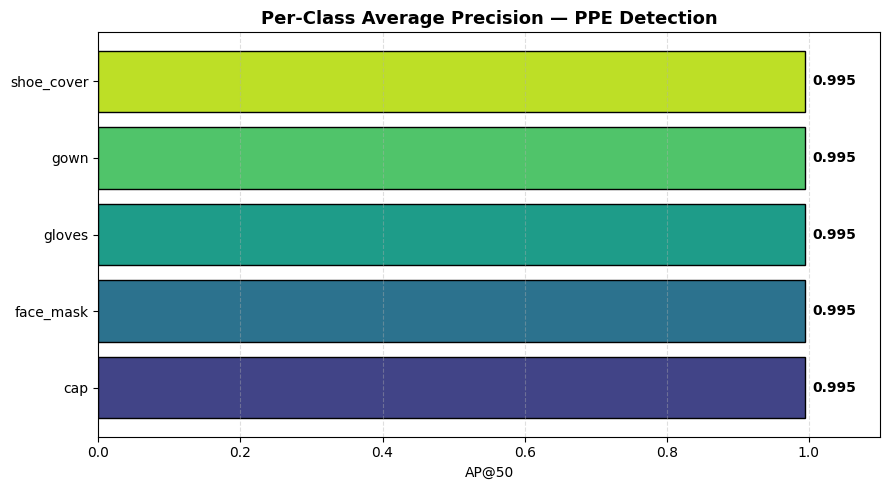

In [ ]:
# ============================================================
# CELL 13: Per-Class Performance (Best Model)
# ============================================================
ap_idx  = best_metrics_obj.box.ap_class_index
ap50    = best_metrics_obj.box.ap50

df_class = pd.DataFrame({
    "PPE Class": [CLASS_NAMES[i] for i in ap_idx],
    "AP@50"    : np.round(ap50, 4),
}).sort_values("AP@50", ascending=True)

print("📋 Per-Class Performance (Best Model)")
print(df_class.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(df_class)))
bars = ax.barh(df_class["PPE Class"], df_class["AP@50"],
               color=colors, edgecolor="black")
for bar, val in zip(bars, df_class["AP@50"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontweight="bold")
ax.set_xlim(0, 1.1)
ax.set_xlabel("AP@50")
ax.set_title("Per-Class Average Precision — PPE Detection",
             fontsize=13, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("per_class_ap.png", dpi=150)
plt.show()

📂 Looking for:
/content/runs/detect/ppe_detection/eval_c2/confusion_matrix.png


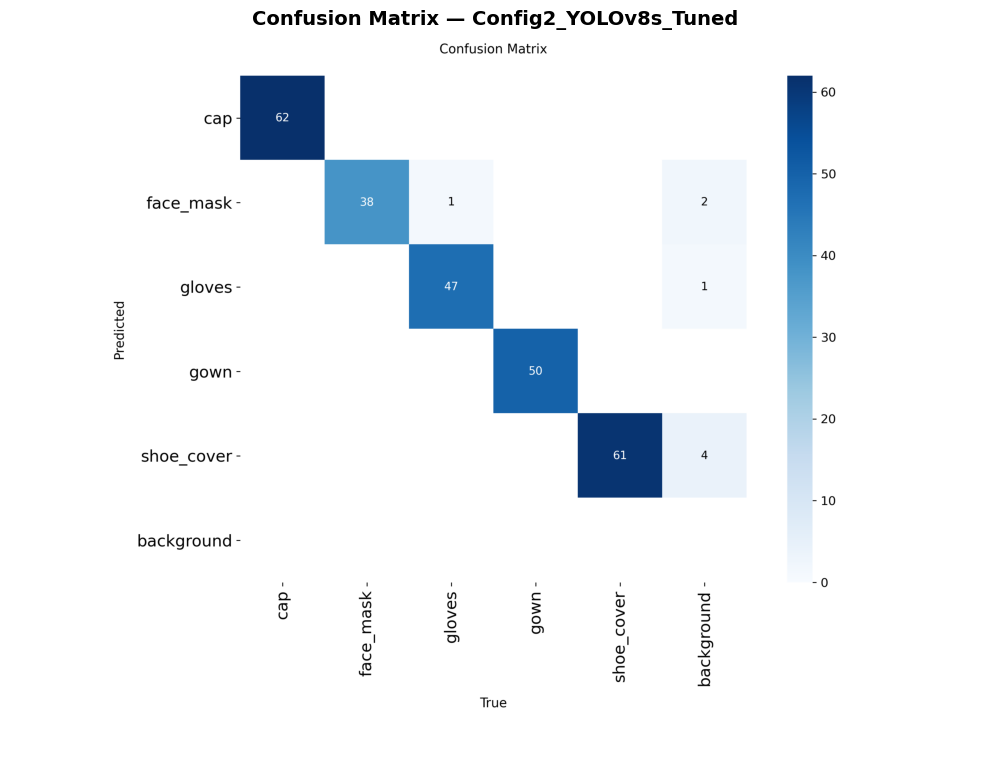


✅ Confusion matrix displayed successfully


In [ ]:
# ============================================================
# CELL 14: Display Confusion Matrix
# ============================================================

# ------------------------------------------------------------
# Base runs directory
# ------------------------------------------------------------
RUNS_DIR = Path("/content/runs/detect")

# ------------------------------------------------------------
# Select evaluation folder based on winner
# ------------------------------------------------------------
eval_folder = "eval_c2" if winner_name == config2["name"] else "eval_c1"

# ------------------------------------------------------------
# Full confusion matrix path
# ------------------------------------------------------------
cm_path = (
    RUNS_DIR /
    PROJECT /
    eval_folder /
    "confusion_matrix.png"
)

print("📂 Looking for:")
print(cm_path)

# ------------------------------------------------------------
# Display image if exists
# ------------------------------------------------------------
if cm_path.exists():

    img = Image.open(cm_path)

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Confusion Matrix — {winner_name}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    print("\n✅ Confusion matrix displayed successfully")

else:
    print(f"\n⚠️ File not found:\n{cm_path}")

    # Optional debug
    print("\n📂 Available folders:")

    base_dir = RUNS_DIR / PROJECT

    if base_dir.exists():
        for item in base_dir.iterdir():
            print("-", item.name)

📂 Looking for:
/content/runs/detect/ppe_detection/Config2_YOLOv8s_Tuned/results.csv

✅ CSV Loaded Successfully
Columns:

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


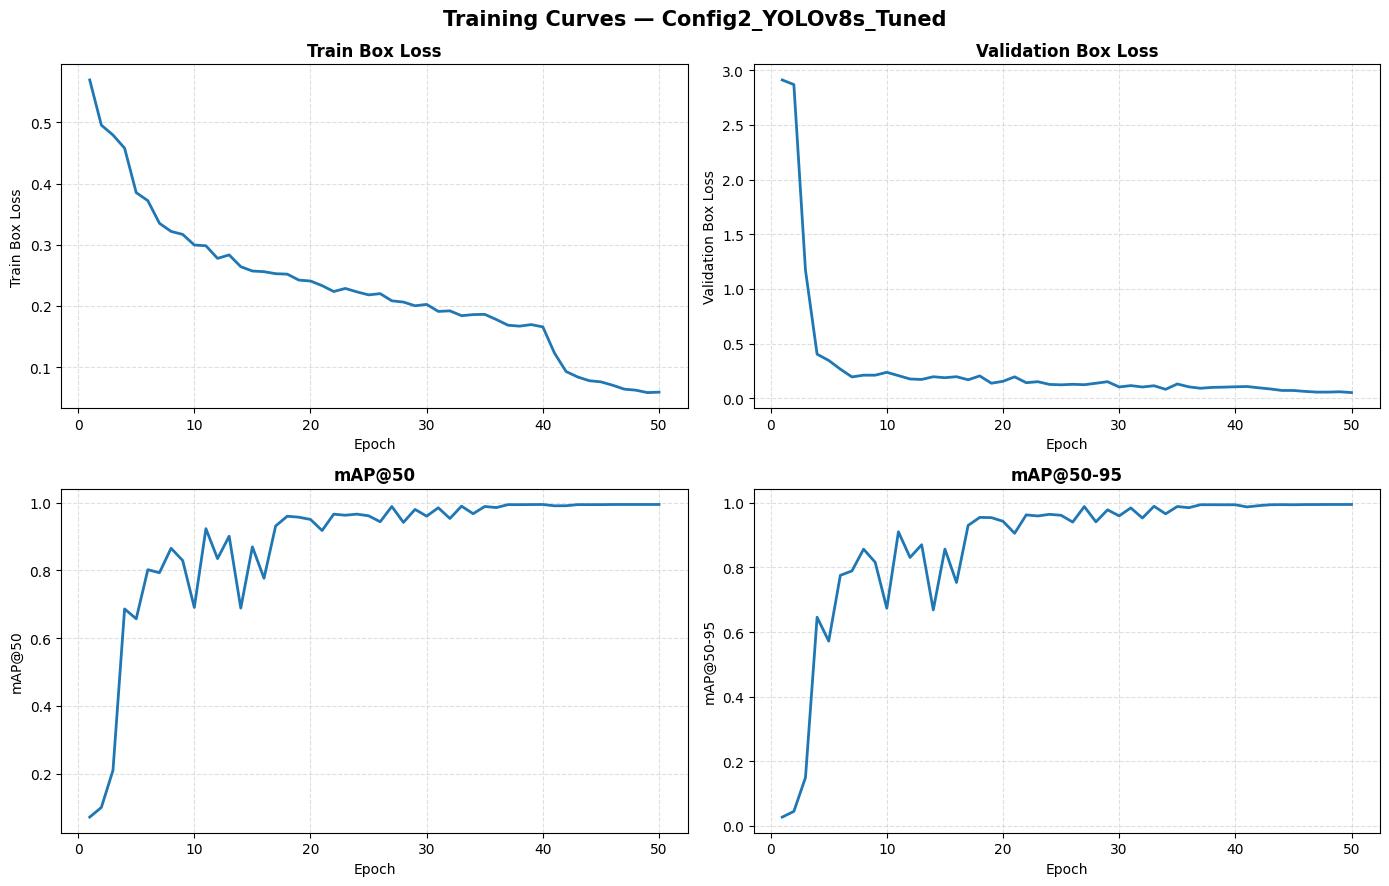


✅ Training curves saved as:
training_curves.png


In [ ]:
# ============================================================
# CELL 15: Training Curves
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Base runs directory
# ------------------------------------------------------------
RUNS_DIR = Path("/content/runs/detect")

# ------------------------------------------------------------
# Select best config automatically
# ------------------------------------------------------------
best_config_name = winner_name

# ------------------------------------------------------------
# Full path to results.csv
# ------------------------------------------------------------
results_csv = (
    RUNS_DIR /
    PROJECT /
    best_config_name /
    "results.csv"
)

print("📂 Looking for:")
print(results_csv)

# ------------------------------------------------------------
# Check file exists
# ------------------------------------------------------------
if not results_csv.exists():

    print(f"\n⚠️ results.csv not found:\n{results_csv}")

    # Debug folders
    base_dir = RUNS_DIR / PROJECT

    print("\n📂 Available experiment folders:")

    if base_dir.exists():
        for item in base_dir.iterdir():
            print("-", item.name)

else:

    # --------------------------------------------------------
    # Load CSV
    # --------------------------------------------------------
    df_res = pd.read_csv(results_csv)

    # Clean column names
    df_res.columns = df_res.columns.str.strip()

    print("\n✅ CSV Loaded Successfully")
    print("Columns:\n")
    print(df_res.columns.tolist())

    # --------------------------------------------------------
    # Create plots
    # --------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    plots = [
        ("train/box_loss",      "Train Box Loss"),
        ("val/box_loss",        "Validation Box Loss"),
        ("metrics/mAP50(B)",    "mAP@50"),
        ("metrics/mAP50-95(B)", "mAP@50-95"),
    ]

    for ax, (col, title) in zip(axes.flat, plots):

        if col in df_res.columns:

            ax.plot(
                df_res["epoch"],
                df_res[col],
                linewidth=2
            )

            ax.set_title(title, fontweight="bold")
            ax.set_xlabel("Epoch")
            ax.set_ylabel(title)

            ax.grid(
                linestyle="--",
                alpha=0.4
            )

        else:
            ax.set_title(f"{title}\n(Not Found)")
            ax.axis("off")

    # --------------------------------------------------------
    # Main title
    # --------------------------------------------------------
    plt.suptitle(
        f"Training Curves — {best_config_name}",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------
    plt.savefig(
        "training_curves.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("\n✅ Training curves saved as:")
    print("training_curves.png")

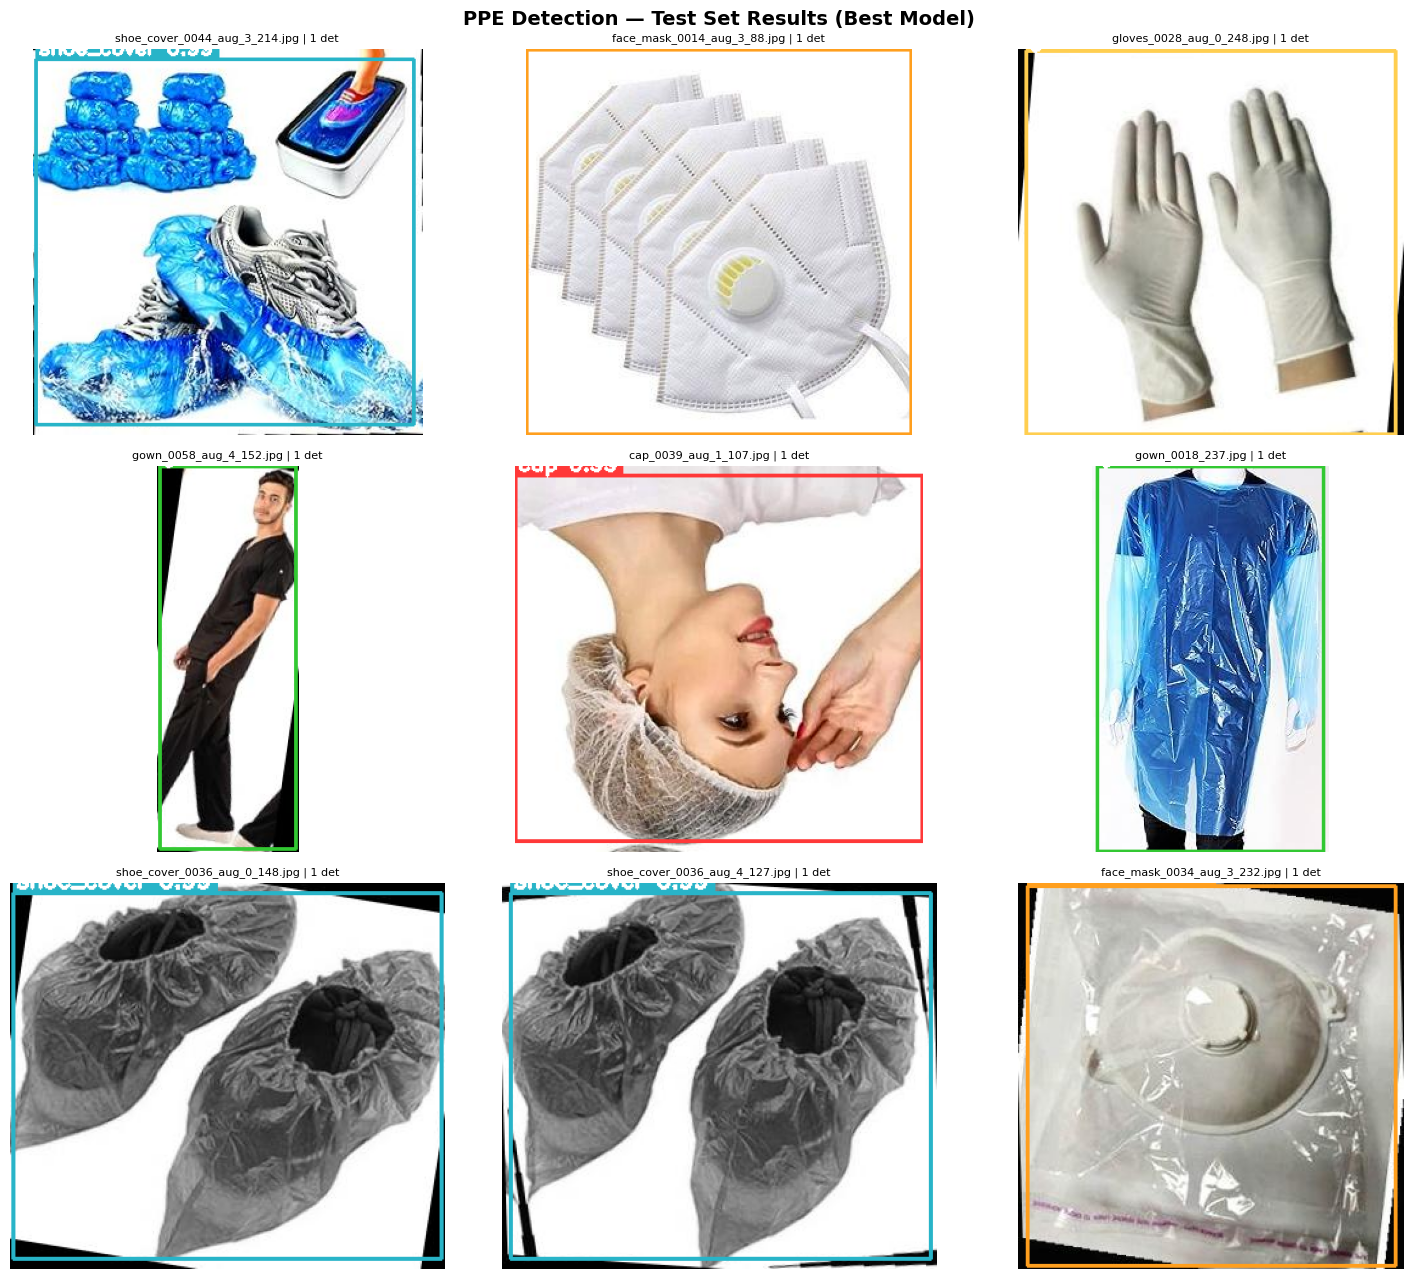

In [ ]:
# ============================================================
# CELL 16: Visual Detection Results on Test Images
# ============================================================
def draw_detection(frame, x1, y1, x2, y2, name, conf, cls_id):
    palette = [
        (255,56,56), (255,159,30), (255,206,80), (50,200,50),
        (40,180,200), (100,100,255), (200,80,255)
    ]
    color = palette[cls_id % len(palette)]
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    label = f"{name} {conf:.2f}"
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    cv2.rectangle(frame, (x1, y1-th-7), (x1+tw+4, y1), color, -1)
    cv2.putText(frame, label, (x1+2, y1-4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 2)

test_dir = YOLO_DIR / "images" / "test"
test_imgs = list(test_dir.glob("*.*"))
sample = random.sample(test_imgs, min(9, len(test_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for ax, p in zip(axes.flat, sample):
    res = best_model(str(p), conf=0.25, verbose=False)
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    for box in res[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cid  = int(box.cls[0])
        conf = float(box.conf[0])
        draw_detection(img, x1, y1, x2, y2, CLASS_NAMES[cid], conf, cid)
    ax.imshow(img)
    ax.set_title(f"{p.name} | {len(res[0].boxes)} det", fontsize=8)
    ax.axis("off")

plt.suptitle("PPE Detection — Test Set Results (Best Model)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("detection_results.png", dpi=150)
plt.show()

🔄 Evaluating pretrained YOLOv8n (no fine-tuning)...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 675.0±390.3 MB/s, size: 15.6 KB)
val: Scanning /content/ppe_yolo_dataset/labels/test.cache... 259 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 259/259 77.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 6.7it/s 2.6s
                   all        259        259      0.889      0.152      0.122     0.0923
                person         62         62      0.444      0.758      0.407      0.315
               bicycle         38         38          1          0     0.0536     0.0394
                   car         48         48          1          0      0.044     0.0257
            motorcycle         50         50          1          0          0

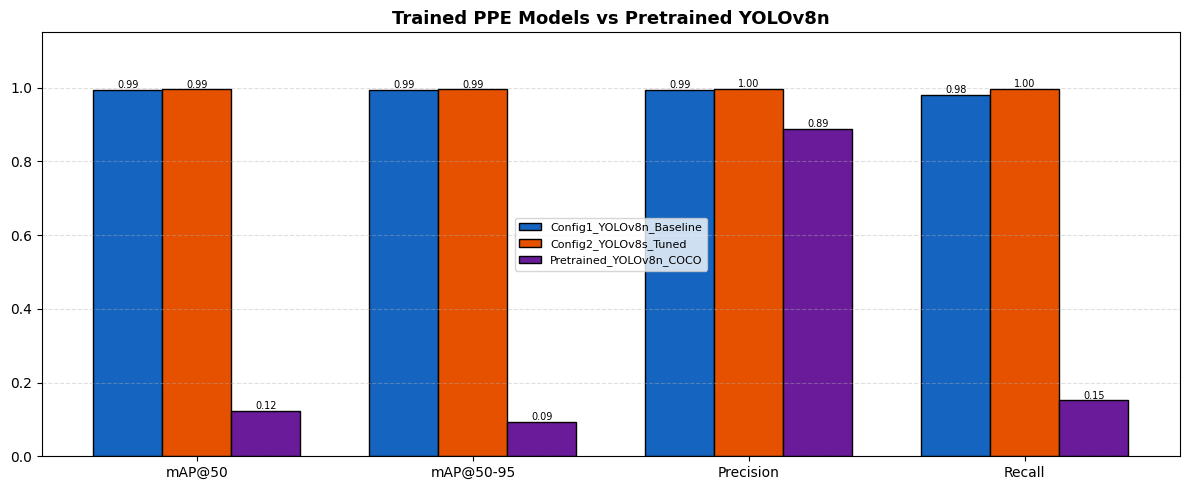


💡 The pretrained COCO model has near-zero performance on PPE classes
   because COCO doesn't include PPE → fine-tuning was essential.


In [ ]:
# ============================================================
# CELL 17: Compare with Pretrained YOLOv8 (Stock COCO weights)
# ============================================================
print("🔄 Evaluating pretrained YOLOv8n (no fine-tuning)...")
pretrained = YOLO("yolov8n.pt")
metrics_pre = pretrained.val(
    data=YAML_PATH, split="test", imgsz=IMG_SIZE,
    project=PROJECT, name="eval_pretrained", plots=False,
)

row_pre = extract(metrics_pre, "Pretrained_YOLOv8n_COCO")
df_final = pd.DataFrame([row1, row2, row_pre]).set_index("Config")

print("\n📊 Final Comparison: Trained vs Pretrained")
print("=" * 70)
print(df_final.to_string())

# Plot
metrics_show = ["mAP@50", "mAP@50-95", "Precision", "Recall"]
x = np.arange(len(metrics_show)); w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#1565C0", "#E65100", "#6A1B9A"]
for i, (cfg, c) in enumerate(zip(df_final.index, colors)):
    offset = (i - 1) * w
    vals = df_final.loc[cfg, metrics_show].values
    bars = ax.bar(x + offset, vals, w, label=cfg, color=c, edgecolor="black")
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f"{b.get_height():.2f}", ha="center", fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(metrics_show)
ax.set_ylim(0, 1.15); ax.legend(fontsize=8)
ax.set_title("Trained PPE Models vs Pretrained YOLOv8n",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=150)
plt.show()

print("\n💡 The pretrained COCO model has near-zero performance on PPE classes")
print("   because COCO doesn't include PPE → fine-tuning was essential.")

In [ ]:
from pathlib import Path

train_imgs = set([p.name for p in Path("/content/ppe_yolo_dataset/images/train").glob("*")])
val_imgs   = set([p.name for p in Path("/content/ppe_yolo_dataset/images/val").glob("*")])
test_imgs  = set([p.name for p in Path("/content/ppe_yolo_dataset/images/test").glob("*")])

print("Train ∩ Val :", len(train_imgs & val_imgs))
print("Train ∩ Test:", len(train_imgs & test_imgs))
print("Val ∩ Test  :", len(val_imgs & test_imgs))

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0
